In [6]:
import matplotlib.pyplot as plt
from PIL import Image

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    i = 1
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Rank: {i}")
        i += 1
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [7]:
from pathlib import Path
from R2 import FashionEmbedder, FashionSearchEngine

INDEX_PATH = "vdb/R2.bin"
embedder = FashionEmbedder()
search_engine = FashionSearchEngine(embedder=embedder)

try:
    search_engine.load(INDEX_PATH)
    print("Loaded existing index.")
except Exception as e:
    print(f"Could not load index ({e}). Building a new one...")
    dataset_dir = Path("dataset/images")
    image_paths = sorted(
        p for p in dataset_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )

    search_engine.build_index(image_paths)
    Path(INDEX_PATH).parent.mkdir(parents=True, exist_ok=True)
    search_engine.save(INDEX_PATH)

Using device: mps


Loading weights: 100%|██████████| 472/472 [00:00<00:00, 67380.67it/s]


Loaded 3200 indexed images.
Loaded existing index.


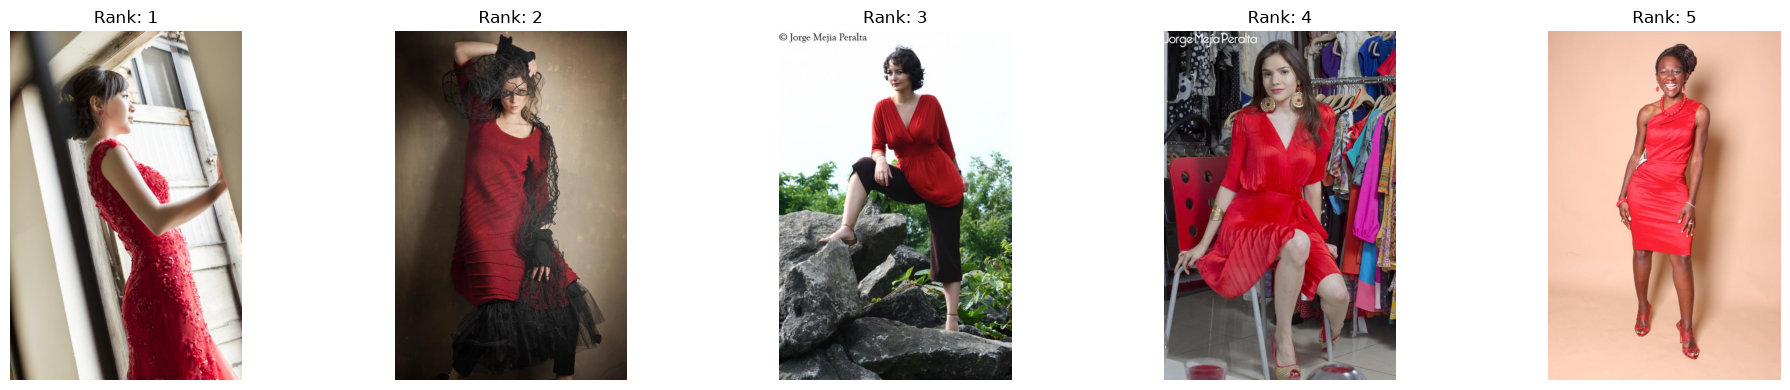

In [8]:
results = search_engine.query("vintage red dress", k_initial=30, k_final=5)
show_results(results)

In [2]:
from MultiHead import FashionCLIPModel, VectorIndex, FashionSearchEngine
from pathlib import Path

model = FashionCLIPModel()

index = VectorIndex()   
db_path = "vdb/multi_retrieve.bin"

index.load(db_path)

if index.index is None:
    embeddings = index.build_from_dir(Path("./dataset/images"), model)
    index.save(db_path)

engine = FashionSearchEngine(index, model)
results = engine.retrieve("vintage minimalist look", embeddings)

/Users/armaanjagirdar/glance_task/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: MPS


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8703.64it/s]


Loaded existing index and 3200 paths.


NameError: name 'embeddings' is not defined

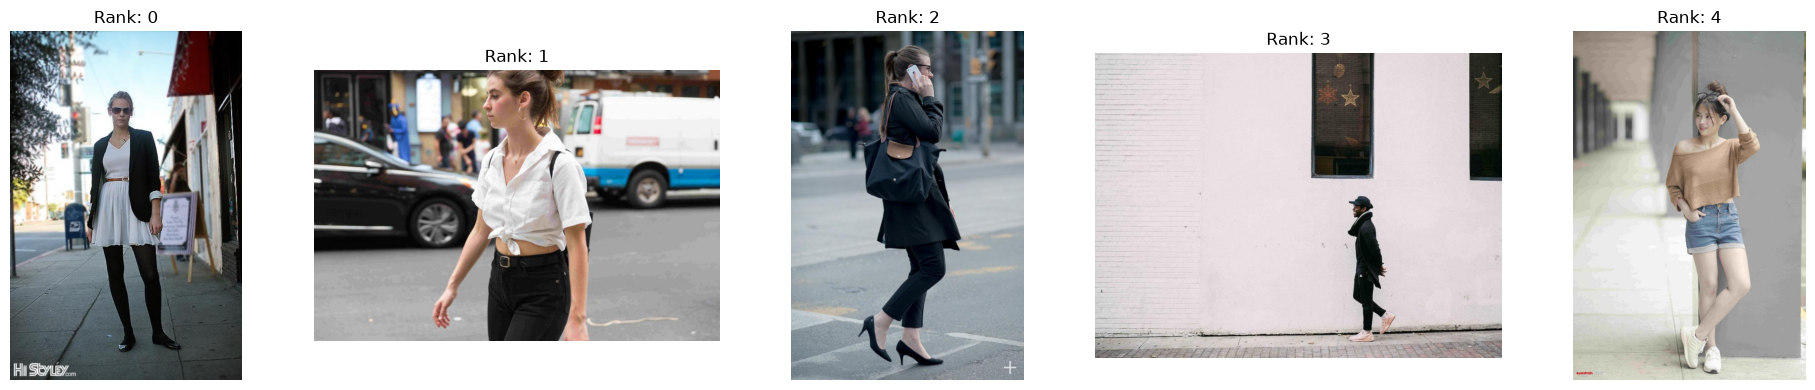

In [3]:
show_results(results)